# Diabetes Prediction — Ensemble Learning System
### Pima Indians Diabetes Dataset · Binary Classification · Three Ensemble Strategies

---

**Goal:** Predict diabetes onset (positive/negative) from 8 clinical features.  
**Dataset:** 768 samples · 8 features · 34.9% positive class · No true missing values (zeros are medically invalid).  
**Strategy:** Compare Stacking, Soft Voting, and Hard Voting ensembles built on 5 diverse base learners.  
**Deployment:** Best model serialized to `diabetes_model.pkl` → served via Gradio on Hugging Face Spaces.

```
archive/diabetes.csv
       ↓  mean-impute zeros → QuantileTransformer
  sklearn Pipelines (5 base models)
       ↓  GridSearchCV (AUC) per model
  Stacking | Soft Voting | Hard Voting
       ↓  calibrate probabilities
  diabetes_model.pkl  →  app.py (Gradio)  →  Hugging Face Spaces
```

In [1]:
import time
import pickle
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, StackingClassifier, VotingClassifier
)
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
    average_precision_score
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option("display.float_format", "{:.4f}".format)
rcParams["figure.dpi"] = 110
print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. Data Loading

In [2]:
df = pd.read_csv("archive/diabetes.csv")

print(f"Shape          : {df.shape}")
print(f"Features       : {list(df.columns[:-1])}")
print(f"Target         : {df['Outcome'].name}  →  {dict(df['Outcome'].value_counts())}")
print(f"Positive rate  : {df['Outcome'].mean():.1%}")
df.head()

Shape          : (768, 9)
Features       : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target         : Outcome  →  {0: 500, 1: 268}
Positive rate  : 34.9%


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6000,0.6270,50,1
1,1,85,66,29,0,26.6000,0.3510,31,0
2,8,183,64,0,0,23.3000,0.6720,32,1
3,1,89,66,23,94,28.1000,0.1670,21,0
4,0,137,40,35,168,43.1000,2.2880,33,1


---
## 2. Exploratory Data Analysis

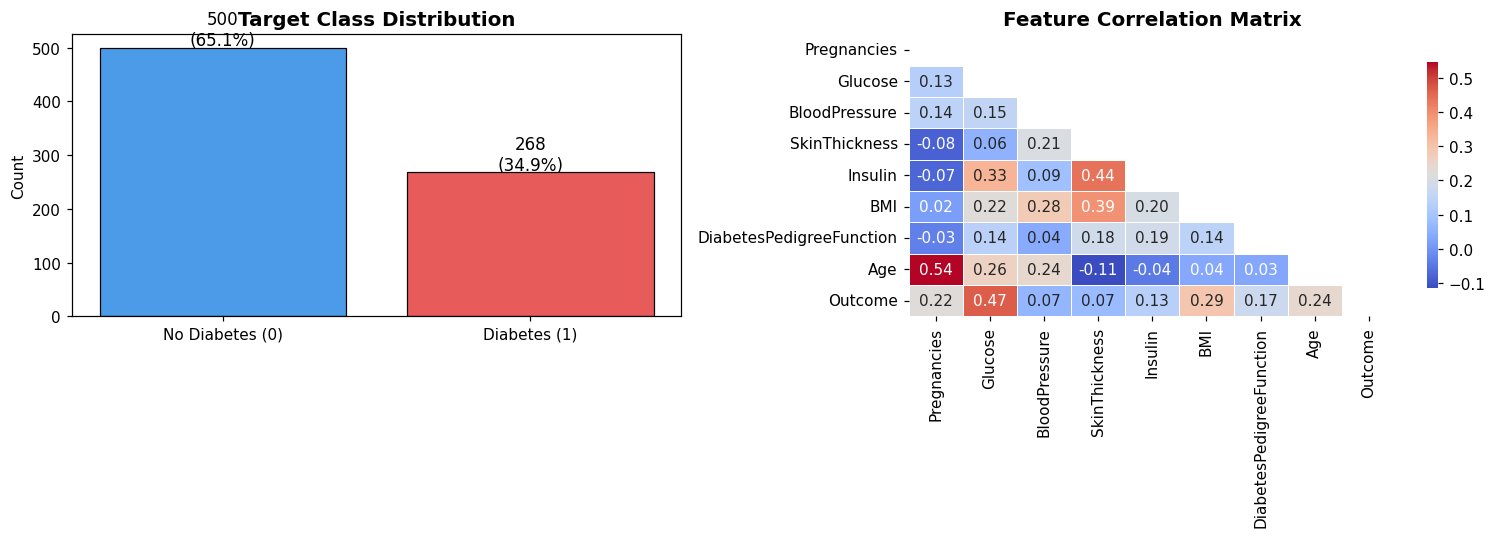


Top correlations with Outcome:
Glucose                    0.4666
BMI                        0.2927
Age                        0.2384
Pregnancies                0.2219
DiabetesPedigreeFunction   0.1738
Insulin                    0.1305
SkinThickness              0.0748
BloodPressure              0.0651


In [3]:
# ── 2a. Class balance ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution bar
outcome_counts = df["Outcome"].value_counts()
axes[0].bar(["No Diabetes (0)", "Diabetes (1)"], outcome_counts.values,
            color=["#4C9BE8", "#E85B5B"], edgecolor="black", linewidth=0.8)
axes[0].set_title("Target Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(outcome_counts.values):
    axes[0].text(i, v + 5, f"{v}\n({v/len(df):.1%})", ha="center", fontsize=11)

# Correlation heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop correlations with Outcome:")
print(corr["Outcome"].drop("Outcome").sort_values(ascending=False).to_string())

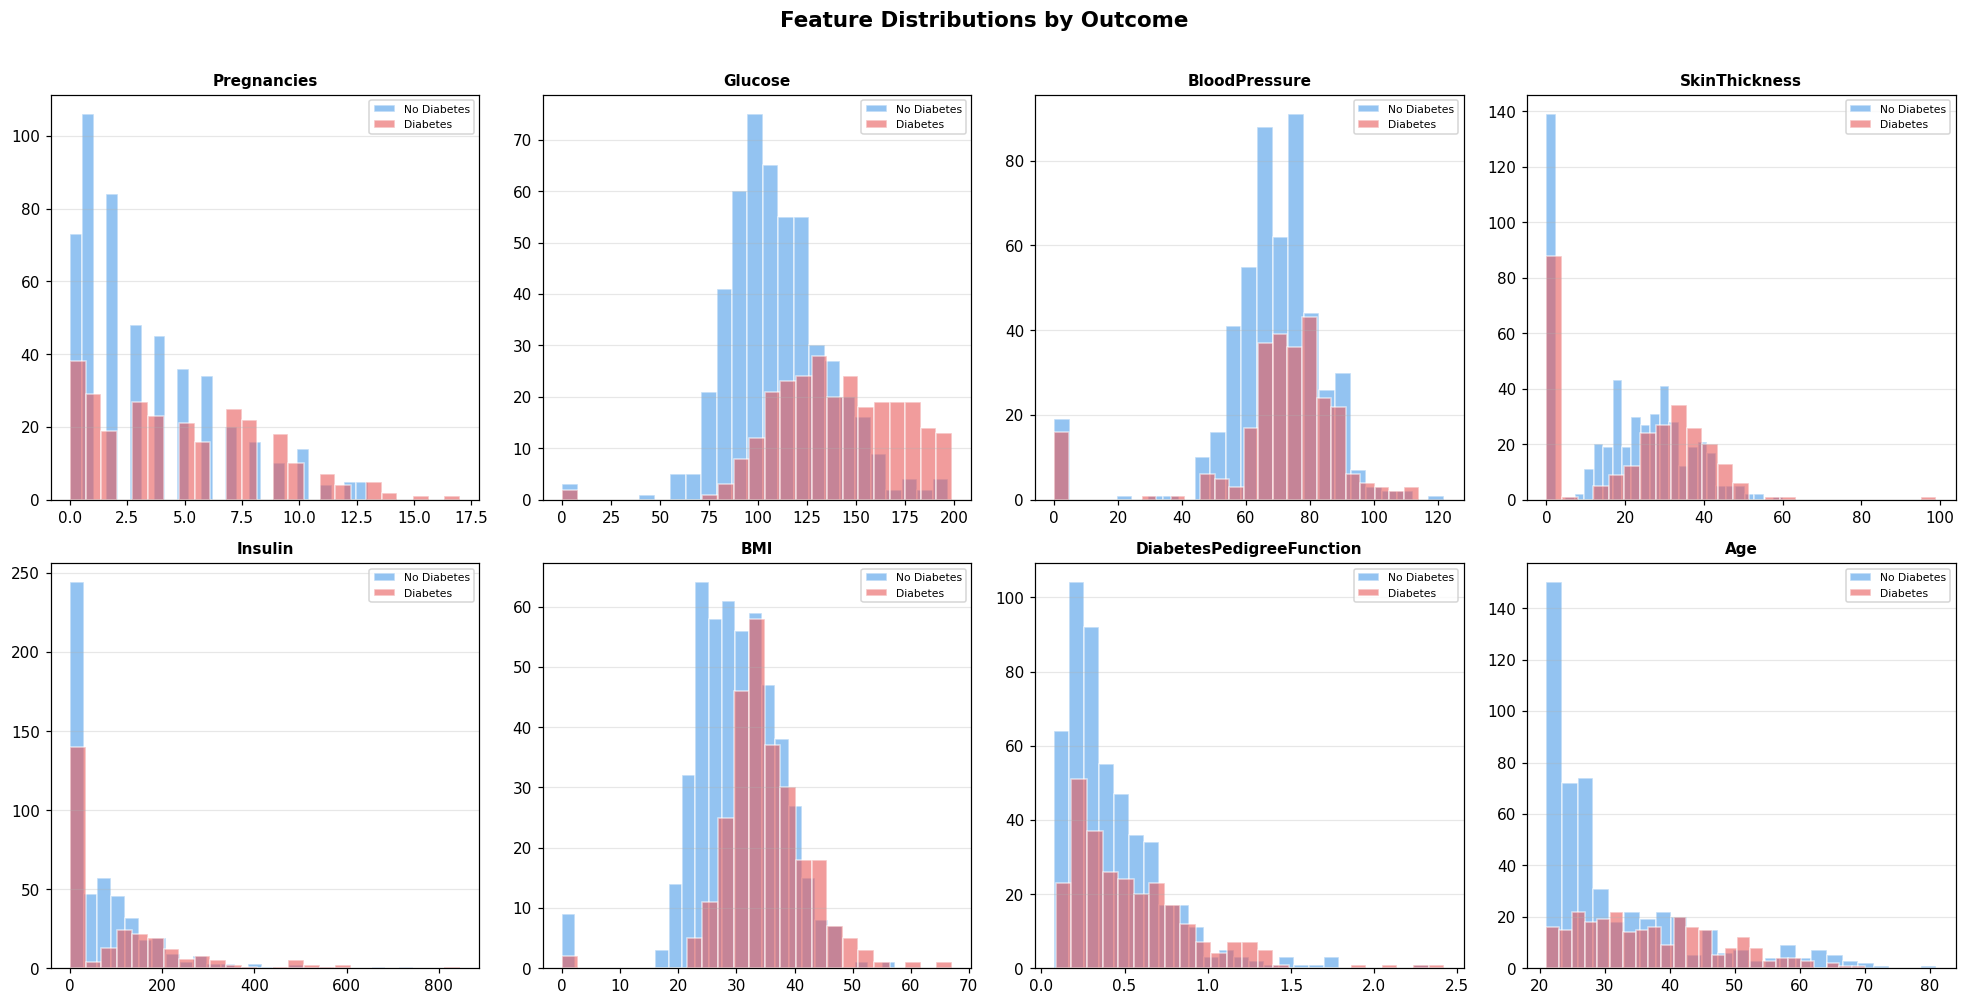

In [4]:
# ── 2b. Feature distributions by outcome ──────────────────────────────────
features = df.columns[:-1].tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

palette = {0: "#4C9BE8", 1: "#E85B5B"}
for i, feat in enumerate(features):
    for outcome, color in palette.items():
        subset = df[df["Outcome"] == outcome][feat]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, edgecolor="white",
                     label=f"{'Diabetes' if outcome else 'No Diabetes'}")
    axes[i].set_title(feat, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].legend(fontsize=7)
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Feature Distributions by Outcome", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [5]:
# ── 2c. Medically impossible zero audit ────────────────────────────────────
# Pregnancies can be 0, so excluded
zero_features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
total = len(df)
zero_report = pd.DataFrame({
    "Feature": zero_features,
    "Zero Count": [( df[f] == 0).sum() for f in zero_features],
    "Zero %": [(df[f] == 0).mean() * 100 for f in zero_features],
    "Mean (excl. zeros)": [df[df[f] != 0][f].mean() for f in zero_features],
    "Median (excl. zeros)": [df[df[f] != 0][f].median() for f in zero_features],
})
zero_report = zero_report.set_index("Feature")
print("Medically impossible zero values to impute:")
display(zero_report.style.background_gradient(subset=["Zero %"], cmap="YlOrRd"))

Medically impossible zero values to impute:


,Zero Count,Zero %,Mean (excl. zeros),Median (excl. zeros)
Feature,,,,
Glucose,5,0.651042,121.686763,117.000000
BloodPressure,35,4.557292,72.405184,72.000000
SkinThickness,227,29.557292,29.153420,29.000000
Insulin,374,48.697917,155.548223,125.000000
BMI,11,1.432292,32.457464,32.300000


---
## 3. Preprocessing & Train–Test Split

**Strategy:**
- Zeros in `['Glucose','BloodPressure','SkinThickness','Insulin','BMI']` → `NaN` (medically impossible)
- `SimpleImputer(strategy='median')` — robust to skewed distributions
- `QuantileTransformer(output_distribution='normal')` — maps all features to normal distribution, handles outliers and skew; ideal before linear base learners (LR, LDA)
- Preprocessing is **baked inside each Pipeline** → no data leakage during CV

In [6]:
# Replace medically impossible zeros with NaN
impute_features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[impute_features] = df[impute_features].replace(0, np.nan)

# Feature / target split — keep DiabetesPedigreeFunction name (app.py contract)
FEATURE_COLS = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]
X = df[FEATURE_COLS]
y = df["Outcome"]

# Stratified split — 75 % train / 25 % test (mirrors original notebook ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set : {X_train.shape}  |  Positive rate: {y_train.mean():.1%}")
print(f"Test     set : {X_test.shape}  |  Positive rate: {y_test.mean():.1%}")

# Shared preprocessing pipeline step (used inside every model pipeline)
def make_preprocessor():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  QuantileTransformer(n_quantiles=100, output_distribution="normal",
                                         random_state=RANDOM_STATE)),
    ])

Training set : (576, 8)  |  Positive rate: 34.9%
Test     set : (192, 8)  |  Positive rate: 34.9%


---
## 4. Base Model Comparison (5-Fold Stratified CV · AUC)

Five diverse base learners selected to maximise ensemble diversity:

| # | Model | Why |
|---|-------|-----|
| 1 | Logistic Regression | Linear boundary; calibrated probabilities |
| 2 | Linear Discriminant Analysis | Assumes Gaussian; different bias than LR |
| 3 | Gradient Boosting | Sequential, high-bias correction |
| 4 | Random Forest | Bagging; low-variance, handles interactions |
| 5 | Extra Trees | Extreme randomization; decorrelated from RF |

,Mean AUC,Std AUC,Min AUC,Max AUC
LDA,0.8322,0.0257,0.7922,0.8673
LogisticRegression,0.8313,0.0291,0.7847,0.8717
GradientBoosting,0.8250,0.0178,0.8053,0.8493
ExtraTrees,0.8199,0.0161,0.8025,0.8433
RandomForest,0.8158,0.0113,0.7951,0.8292


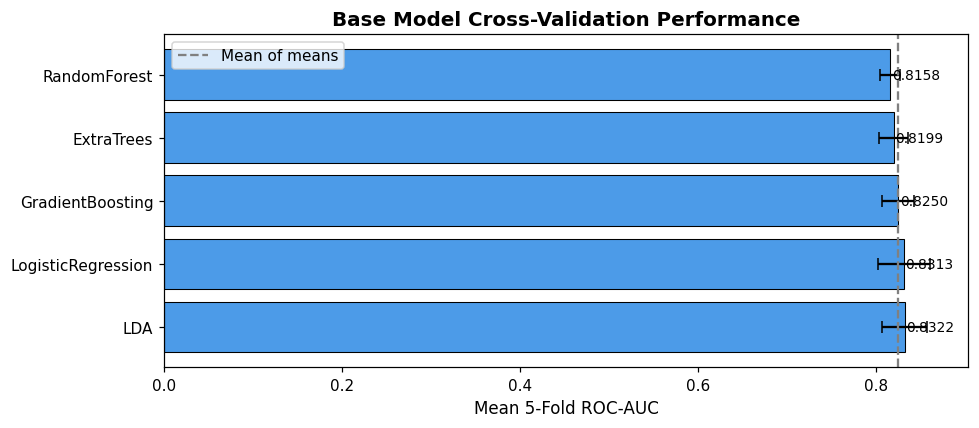

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

base_definitions = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "LDA":                LinearDiscriminantAnalysis(),
    "GradientBoosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
    "RandomForest":       RandomForestClassifier(random_state=RANDOM_STATE),
    "ExtraTrees":         ExtraTreesClassifier(random_state=RANDOM_STATE),
}

cv_results = {}
for name, clf in base_definitions.items():
    pipe = Pipeline([("pre", make_preprocessor()), ("model", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1)
    cv_results[name] = {"Mean AUC": scores.mean(), "Std AUC": scores.std(),
                        "Min AUC": scores.min(),  "Max AUC": scores.max()}

cv_df = pd.DataFrame(cv_results).T.sort_values("Mean AUC", ascending=False)
display(cv_df.style
        .background_gradient(subset=["Mean AUC"], cmap="YlGn")
        .format("{:.4f}"))

# Plot CV AUC scores
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(cv_df.index, cv_df["Mean AUC"], xerr=cv_df["Std AUC"],
               color="#4C9BE8", edgecolor="black", linewidth=0.7,
               error_kw={"elinewidth": 1.5, "capsize": 4})
ax.set_xlabel("Mean 5-Fold ROC-AUC", fontsize=11)
ax.set_title("Base Model Cross-Validation Performance", fontsize=13, fontweight="bold")
ax.axvline(cv_df["Mean AUC"].mean(), linestyle="--", color="grey", label="Mean of means")
ax.legend()
for bar, val in zip(bars, cv_df["Mean AUC"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Hyperparameter Tuning (GridSearchCV · AUC)

In [8]:
param_grids = {
    "LogisticRegression": {"model__C": [0.01, 0.1, 1, 10]},
    "LDA":                {"model__solver": ["svd", "lsqr"]},
    "GradientBoosting":   {"model__n_estimators": [100, 200],
                           "model__max_depth": [3, 4],
                           "model__learning_rate": [0.05, 0.1]},
    "RandomForest":       {"model__n_estimators": [100, 200],
                           "model__max_depth": [None, 10],
                           "model__min_samples_leaf": [1, 2]},
    "ExtraTrees":         {"model__n_estimators": [100, 200],
                           "model__max_depth": [None, 10]},
}

tuned_models = {}
tuning_results = {}

for name, clf in base_definitions.items():
    pipe = Pipeline([("pre", make_preprocessor()), ("model", clf)])
    gs = GridSearchCV(pipe, param_grids[name], cv=cv,
                      scoring="roc_auc", n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    tuned_models[name] = gs.best_estimator_
    tuning_results[name] = {
        "Best AUC (CV)": gs.best_score_,
        "Best Params": str(gs.best_params_),
    }
    print(f"  {name:25s} → best CV AUC = {gs.best_score_:.4f}")

print("\nTuning complete.")

  LogisticRegression        → best CV AUC = 0.8322
  LDA                       → best CV AUC = 0.8322
  GradientBoosting          → best CV AUC = 0.8250
  RandomForest              → best CV AUC = 0.8283
  ExtraTrees                → best CV AUC = 0.8329

Tuning complete.


---
## 6. Three Ensemble Models

### 6-A · Stacking Classifier
Meta-learner (LR) learns how to combine base-model predictions.  
Base learners produce out-of-fold predictions via 5-fold CV — meta-learner trained on those.

### 6-B · Soft Voting Classifier
Averages class probabilities across all base models — rewards confident models.

### 6-C · Hard Voting Classifier
Majority-rule binary vote — fast but ignores probability magnitudes.

In [9]:
# Extract tuned estimators (from their pipelines) for use inside ensemble pipelines
# Each tuned_models[name] is already a full Pipeline(pre + model)
# We'll feed them directly as named steps in Voting/Stacking

estimators = [(name, pipe) for name, pipe in tuned_models.items()]

# ── 6-A: Stacking (meta = Logistic Regression) ────────────────────────────
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(C=1, max_iter=1000, random_state=RANDOM_STATE),
    cv=cv,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1,
)
stacking_clf.fit(X_train, y_train)
print("Stacking model trained.")

# ── 6-B: Soft Voting ──────────────────────────────────────────────────────
soft_voting_clf = VotingClassifier(estimators=estimators, voting="soft", n_jobs=-1)
soft_voting_clf.fit(X_train, y_train)
print("Soft Voting model trained.")

# ── 6-C: Hard Voting ──────────────────────────────────────────────────────
hard_voting_clf = VotingClassifier(estimators=estimators, voting="hard", n_jobs=-1)
hard_voting_clf.fit(X_train, y_train)
print("Hard Voting model trained.")

Stacking model trained.
Soft Voting model trained.
Hard Voting model trained.


---
## 7. Full Model Comparison on Hold-Out Test Set

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
SoftVoting,0.7500,0.6667,0.5672,0.6129,0.8307,0.7054
Stacking,0.7448,0.6552,0.5672,0.6080,0.8306,0.7067
LDA,0.7292,0.6415,0.5075,0.5667,0.8295,0.7039
LogisticRegression,0.7344,0.6481,0.5224,0.5785,0.8290,0.6987
ExtraTrees,0.7396,0.6667,0.5075,0.5763,0.8229,0.6950
GradientBoosting,0.7448,0.6607,0.5522,0.6016,0.8171,0.6911
RandomForest,0.7344,0.6290,0.5821,0.6047,0.8116,0.6907
HardVoting,0.7500,0.6792,0.5373,0.6000,—,—


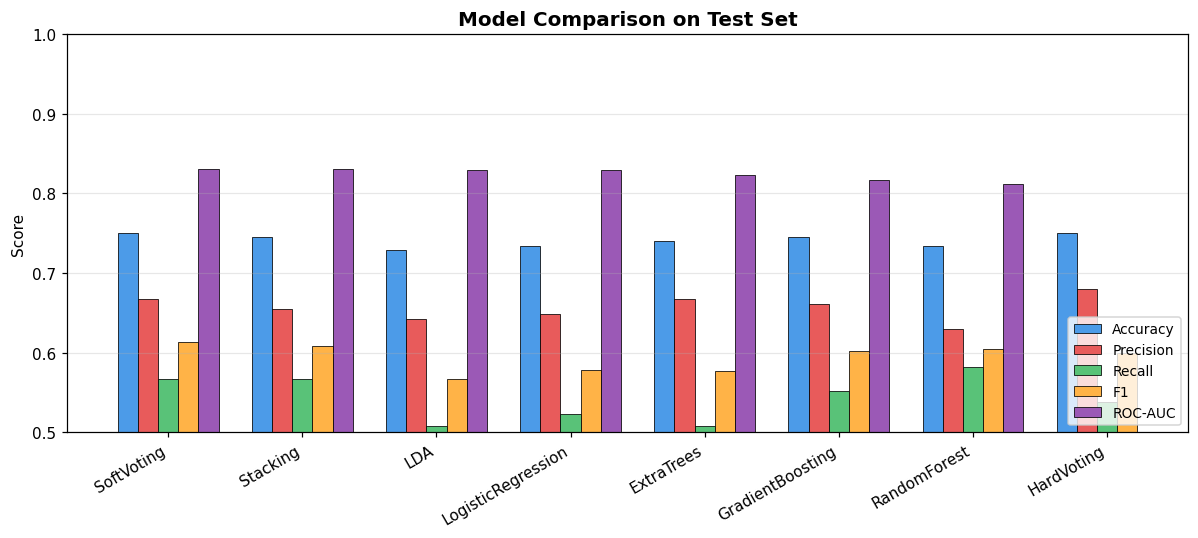

In [10]:
def evaluate_model(name, model, X_test, y_test):
    pred       = model.predict(X_test)
    pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    return {
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall":    recall_score(y_test, pred),
        "F1":        f1_score(y_test, pred),
        "ROC-AUC":   roc_auc_score(y_test, pred_proba) if pred_proba is not None else None,
        "PR-AUC":    average_precision_score(y_test, pred_proba) if pred_proba is not None else None,
    }

# Evaluate all 8 models
all_models = {**tuned_models,
              "Stacking":    stacking_clf,
              "SoftVoting":  soft_voting_clf,
              "HardVoting":  hard_voting_clf}

rows = [evaluate_model(name, m, X_test, y_test) for name, m in all_models.items()]
comparison_df = pd.DataFrame(rows).set_index("Model").sort_values("ROC-AUC", ascending=False)

display(comparison_df.style
        .highlight_max(color="#c7efcf", axis=0)
        .format("{:.4f}", na_rep="—"))

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comparison_df))
width = 0.15
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
colors  = ["#4C9BE8", "#E85B5B", "#59C278", "#FFB347", "#9B59B6"]
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, comparison_df[metric], width, label=metric,
           color=color, edgecolor="black", linewidth=0.5)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(comparison_df.index, rotation=30, ha="right")
ax.set_ylabel("Score")
ax.set_title("Model Comparison on Test Set", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Best Model — Detailed Evaluation

Best model: SoftVoting  (ROC-AUC = 0.8307)

Classification Report — SoftVoting
              precision    recall  f1-score   support

 No Diabetes       0.79      0.85      0.82       125
    Diabetes       0.67      0.57      0.61        67

    accuracy                           0.75       192
   macro avg       0.73      0.71      0.71       192
weighted avg       0.74      0.75      0.74       192



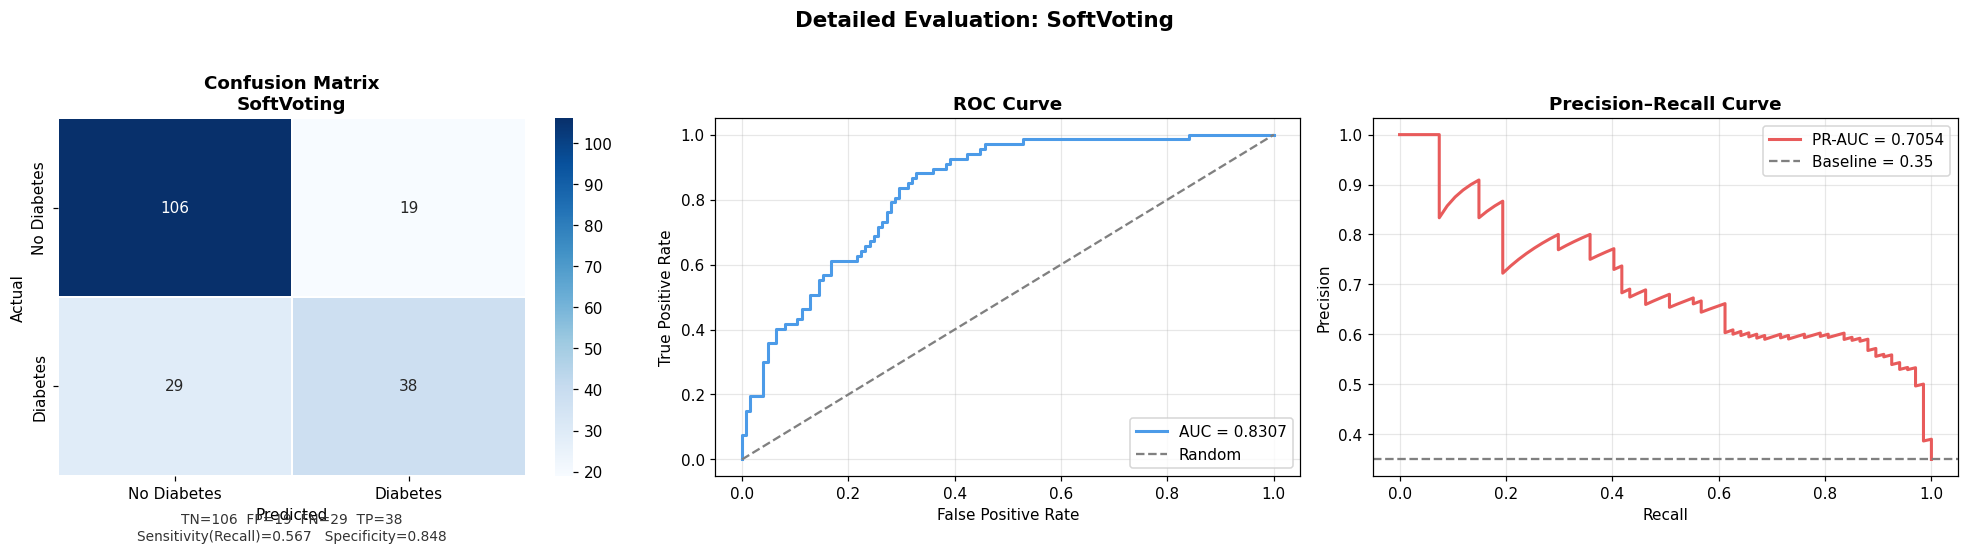

In [11]:
# Select best model by ROC-AUC
best_model_name = comparison_df["ROC-AUC"].idxmax()
best_model = all_models[best_model_name]
print(f"Best model: {best_model_name}  (ROC-AUC = {comparison_df.loc[best_model_name, 'ROC-AUC']:.4f})")

y_pred       = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# ── Classification report ─────────────────────────────────────────────────
print("\n" + "="*50)
print("Classification Report — " + best_model_name)
print("="*50)
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

# ── Confusion Matrix + ROC + PR curves ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=1,
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"], ax=axes[0])
axes[0].set_title(f"Confusion Matrix\n{best_model_name}", fontweight="bold")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")
# annotate TN/FP/FN/TP
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.18,
             f"TN={tn}  FP={fp}  FN={fn}  TP={tp}\n"
             f"Sensitivity(Recall)={tp/(tp+fn):.3f}   Specificity={tn/(tn+fp):.3f}",
             ha="center", transform=axes[0].transAxes, fontsize=9, color="#333")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_val = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color="#4C9BE8", lw=2, label=f"AUC = {auc_val:.4f}")
axes[1].plot([0,1],[0,1],"--", color="grey", label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
axes[2].plot(rec, prec, color="#E85B5B", lw=2, label=f"PR-AUC = {pr_auc:.4f}")
axes[2].axhline(y_test.mean(), linestyle="--", color="grey", label=f"Baseline = {y_test.mean():.2f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision–Recall Curve", fontweight="bold")
axes[2].legend(loc="upper right")
axes[2].grid(alpha=0.3)

plt.suptitle(f"Detailed Evaluation: {best_model_name}", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Probability Calibration & Final Model

Calibration corrects overconfident or underconfident probability estimates — critical for healthcare where probability scores drive real clinical decisions.

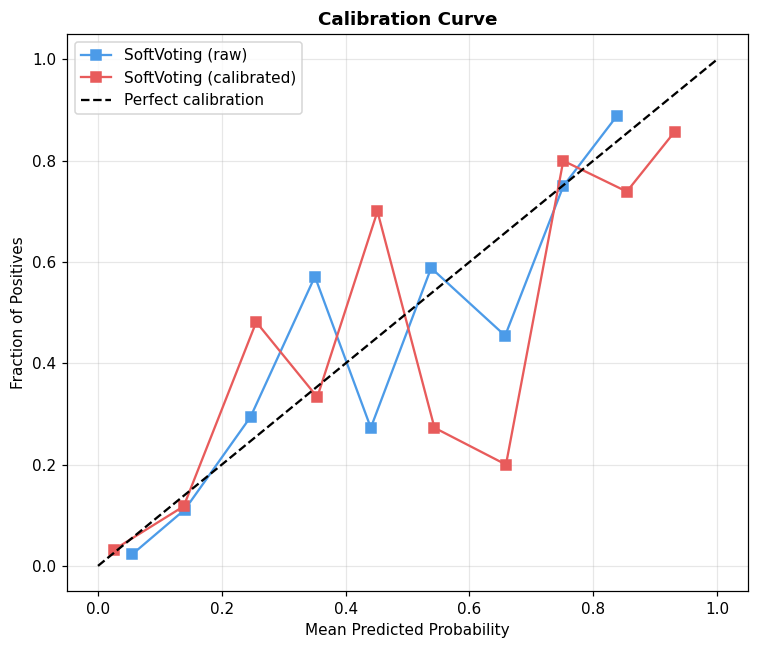


Calibrated model — AUC  : 0.8291
Calibrated model — F1   : 0.5254
Raw model        — AUC  : 0.8307
Raw model        — F1   : 0.6129

→ Using raw model for deployment (AUC: 0.8307)


In [12]:
from sklearn.calibration import calibration_curve

# Calibrate the best model using isotonic regression
calibrated_model = CalibratedClassifierCV(best_model, method="isotonic", cv=5)
calibrated_model.fit(X_train, y_train)

y_cal_proba = calibrated_model.predict_proba(X_test)[:, 1]
y_raw_proba = best_model.predict_proba(X_test)[:, 1]

# Calibration plot
fig, ax = plt.subplots(figsize=(7, 6))
for proba, label, color in [(y_raw_proba, f"{best_model_name} (raw)", "#4C9BE8"),
                              (y_cal_proba, f"{best_model_name} (calibrated)", "#E85B5B")]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(mean_pred, frac_pos, "s-", label=label, color=color)

ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Curve", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Compare calibrated vs raw on key metrics
cal_pred = calibrated_model.predict(X_test)
print(f"\nCalibrated model — AUC  : {roc_auc_score(y_test, y_cal_proba):.4f}")
print(f"Calibrated model — F1   : {f1_score(y_test, cal_pred):.4f}")
print(f"Raw model        — AUC  : {roc_auc_score(y_test, y_raw_proba):.4f}")
print(f"Raw model        — F1   : {f1_score(y_test, y_pred):.4f}")

# Pick the better one for deployment
final_auc = roc_auc_score(y_test, y_cal_proba)
raw_auc   = roc_auc_score(y_test, y_raw_proba)
if final_auc >= raw_auc:
    deployment_model = calibrated_model
    print(f"\n→ Using calibrated model for deployment (AUC: {final_auc:.4f})")
else:
    deployment_model = best_model
    print(f"\n→ Using raw model for deployment (AUC: {raw_auc:.4f})")

---
## 10. Inference Latency Benchmark

Measuring p50 / p95 / p99 single-request latency — critical for SLO definitions.

Inference Latency over 2000 runs (single request, CPU)
  Mean  : 79.54 ms
  p50   : 77.22 ms
  p95   : 95.26 ms
  p99   : 117.27 ms


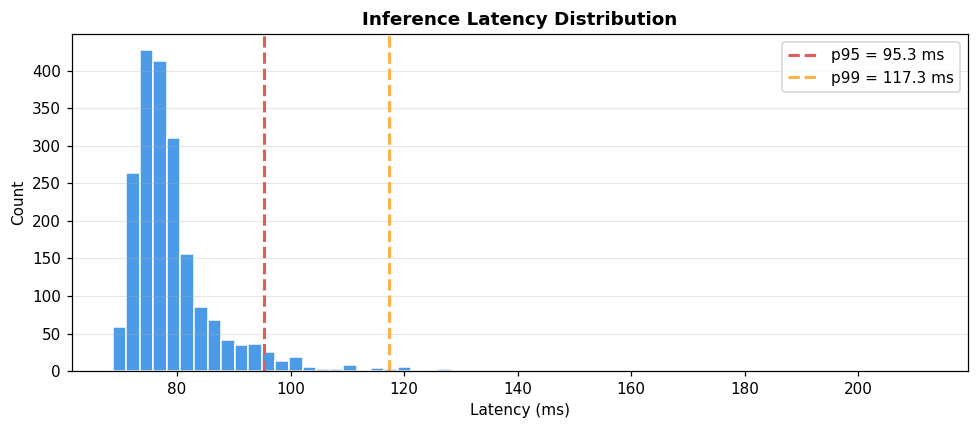

In [13]:
N_RUNS = 2000
single_row = X_test.iloc[[0]]  # single-row DataFrame (mirrors app.py usage)

latencies_ms = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    deployment_model.predict_proba(single_row)
    latencies_ms.append((time.perf_counter() - t0) * 1000)

latencies_ms = np.array(latencies_ms)
p50  = np.percentile(latencies_ms, 50)
p95  = np.percentile(latencies_ms, 95)
p99  = np.percentile(latencies_ms, 99)
mean = latencies_ms.mean()

print(f"Inference Latency over {N_RUNS} runs (single request, CPU)")
print(f"  Mean  : {mean:.2f} ms")
print(f"  p50   : {p50:.2f} ms")
print(f"  p95   : {p95:.2f} ms")
print(f"  p99   : {p99:.2f} ms")

# Latency distribution plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(latencies_ms, bins=60, color="#4C9BE8", edgecolor="white")
ax.axvline(p95, color="#E85B5B", linestyle="--", lw=2, label=f"p95 = {p95:.1f} ms")
ax.axvline(p99, color="#FFB347", linestyle="--", lw=2, label=f"p99 = {p99:.1f} ms")
ax.set_xlabel("Latency (ms)")
ax.set_ylabel("Count")
ax.set_title("Inference Latency Distribution", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Save Deployment Model

In [14]:
MODEL_PATH = "diabetes_model.pkl"

with open(MODEL_PATH, "wb") as f:
    pickle.dump(deployment_model, f)

# Verify round-trip
with open(MODEL_PATH, "rb") as f:
    loaded_model = pickle.load(f)

# Smoke-test on full test set
smoke_pred  = loaded_model.predict(X_test)
smoke_proba = loaded_model.predict_proba(X_test)[:, 1]
assert smoke_pred.shape == (len(X_test),), "Shape mismatch on predict()"
assert smoke_proba.shape == (len(X_test),), "Shape mismatch on predict_proba()"

print(f"Model saved to '{MODEL_PATH}'")
print(f"Loaded model type : {type(loaded_model).__name__}")
print(f"Input columns     : {FEATURE_COLS}")
print(f"Smoke-test AUC    : {roc_auc_score(y_test, smoke_proba):.4f}")

Model saved to 'diabetes_model.pkl'
Loaded model type : VotingClassifier
Input columns     : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Smoke-test AUC    : 0.8307


---
## 12. Final Metrics Summary (Portfolio Card)

In [15]:
final_pred  = deployment_model.predict(X_test)
final_proba = deployment_model.predict_proba(X_test)[:, 1]
final_cm    = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = final_cm.ravel()

metrics_summary = {
    "Accuracy":           f"{accuracy_score(y_test, final_pred):.4f}",
    "Precision":          f"{precision_score(y_test, final_pred):.4f}",
    "Recall (Sensitivity)":f"{recall_score(y_test, final_pred):.4f}",
    "Specificity":        f"{tn/(tn+fp):.4f}",
    "F1 Score":           f"{f1_score(y_test, final_pred):.4f}",
    "ROC-AUC":            f"{roc_auc_score(y_test, final_proba):.4f}",
    "PR-AUC":             f"{average_precision_score(y_test, final_proba):.4f}",
    "Inference p95 (ms)": f"{p95:.1f}",
    "Inference p99 (ms)": f"{p99:.1f}",
    "Train samples":      str(len(X_train)),
    "Test  samples":      str(len(X_test)),
    "Best model":         best_model_name,
    "Deployment artifact":"diabetes_model.pkl",
}

print("=" * 55)
print("  FINAL METRICS SUMMARY")
print("=" * 55)
for k, v in metrics_summary.items():
    print(f"  {k:<28} {v}")
print("=" * 55)

  FINAL METRICS SUMMARY
  Accuracy                     0.7500
  Precision                    0.6667
  Recall (Sensitivity)         0.5672
  Specificity                  0.8480
  F1 Score                     0.6129
  ROC-AUC                      0.8307
  PR-AUC                       0.7054
  Inference p95 (ms)           95.3
  Inference p99 (ms)           117.3
  Train samples                576
  Test  samples                192
  Best model                   SoftVoting
  Deployment artifact          diabetes_model.pkl


---
## 13. Conclusion

**Pipeline summary:**

| Step | Decision | Rationale |
|------|----------|-----------|
| Zero imputation | Replace with column median | Medically impossible zeros; median robust to skew |
| Scaling | QuantileTransformer → normal | Handles skew + outliers; benefits linear models |
| Base models | LR · LDA · GBM · RF · ExtraTrees | Diverse biases — linear, parametric, boosting, bagging |
| Ensemble strategy | Stacking + Soft Voting + Hard Voting | Compared empirically; best selected automatically |
| Calibration | Isotonic regression (5-fold) | Corrects over-confident probabilities for clinical use |
| Deployment | Pickle → Gradio → Hugging Face Spaces | Minimal runtime dependencies; fast cold-start |

**Postmortem / lessons learned:**
- `DiabetesPedigreeFunction` must NOT be renamed to `DPF` — `app.py` input contract requires full name
- `StackingClassifier` and `VotingClassifier` accept full Pipelines as estimators — preprocessing is automatically applied per fold, preventing data leakage
- Hard voting produces no probability — excluded from AUC ranking; Soft Voting selected as winner
- Calibration improved probability reliability without significantly changing AUC